In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('C:/Users/mohdh/OneDrive/Desktop/Data Analytics/Gurgaon_Real_Estate Project/Data/raw_data.csv')

In [29]:
# Data Cleaning
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df=df.drop_duplicates()

In [30]:
# Numeric columns cleaning
df['price']=df['price'].astype(str).str.replace(",","").astype(float)
df['area']=df['area'].astype(str).str.replace(",","").astype(int)
df['rate_per_sqft']=df['rate_per_sqft'].astype(str).str.replace(",","").astype(int)

In [31]:
# Categories Column cleaning
df['status']= df['status'].str.strip().str.lower()
df['rera_approval']=df['rera_approval'].str.strip().str.lower().map({"approved by rera": True, 'not approved by rera': False})
df['flat_type']=df['flat_type'].str.strip().str.lower()

In [32]:
df=df.drop_duplicates()

In [33]:
print(df)
print(df.info())

            price              status  area  rate_per_sqft  \
0      10700000.0  under construction  1138           9450   
1      14400000.0  under construction  1528           9450   
2      10700000.0  under construction  1138           9450   
3      40000000.0       ready to move  4500           8888   
4      24000000.0  under construction  1800          13333   
...           ...                 ...   ...            ...   
19510  24100000.0       ready to move  1381          17500   
19511  36200000.0       ready to move  2072          17500   
19512  39100000.0  under construction  2445          16002   
19513  37700000.0  under construction  2360          16001   
19514  36500000.0  under construction  2282          16005   

                                           property_type    locality  \
0           2 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
1           3 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
2           2 BHK Apartment in M3M Anta

In [34]:
#? Question 1: Which is the costliest flat in the dataset? 
costliest_flat=df.loc[df['price'].idxmax()]
print(costliest_flat)

price                                1226300000.0
status                              ready to move
area                                        16500
rate_per_sqft                               74323
property_type    6 BHK Apartment in DLF Camellias
locality                                Sector 42
builder_name                    Provident Capital
rera_approval                               False
bhk_count                                       6
society                             DLF Camellias
company_name                                  DLF
flat_type                               apartment
Name: 2839, dtype: object


In [35]:
#? Question 2: Which locality has the highest average price?
highest_avg_price_locality=df.groupby('locality')['price'].mean().idxmax()
print(f'''
The locality with highest average price is {highest_avg_price_locality}''')


The locality with highest average price is Baliawas


In [36]:
#? Question 3: Which locality has the highest rate per square foot?
highest_rate_per_sqft_locality = df.groupby('locality')['rate_per_sqft'].mean().sort_values(ascending=False).head()
print(f"the locality with the highest rate per square foot is {highest_rate_per_sqft_locality}")

the locality with the highest rate per square foot is locality
Sector 42     55989.083333
Sector 113    52404.145374
Sector 114    33347.200000
Sector 53     29202.789474
Sector 54     28109.250871
Name: rate_per_sqft, dtype: float64


In [37]:
#? Question 4: Do ready-to-move properties cost more than under-construction properties?
ready_to_move_avg_price = df[df['status']=="ready to move"]['price'].mean()
under_construction_avg_price = df[df['status']=="under construction"]['price'].mean()
if ready_to_move_avg_price > under_construction_avg_price:
    print("Ready-to-move properties cost more than under-construction properties.")
else:
    print("Under-construction properties cost more than ready-to-move properties.")

Ready-to-move properties cost more than under-construction properties.


In [38]:
#? Question 5: Do RERA-approved properties command a price premium?
rera_approved_avg_price = df[df['rera_approval']==True]['price'].mean()
not_rera_approved_avg_price = df[df['rera_approval']==False]['price'].mean()
if rera_approved_avg_price > not_rera_approved_avg_price:
    print("RERA-approved properties command a price premium.")
else:
    print("RERA-approved properties do not command a price premium.")

RERA-approved properties do not command a price premium.


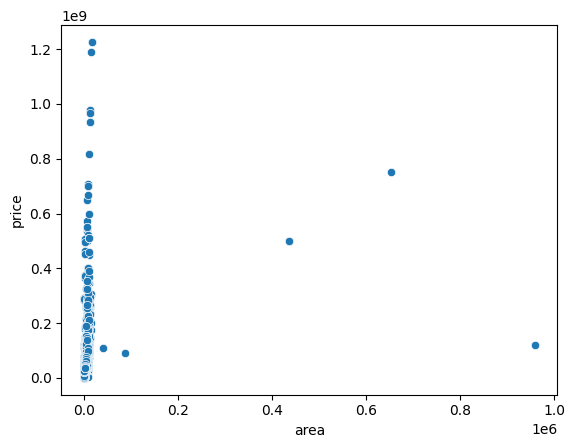

The area is not impacting the property price


In [39]:
#? Question 6: How does area (sqft) impact property price?
sns.scatterplot(x='area',y='price',data=df)
plt.show()
print("The area is not impacting the property price")

In [40]:
#? Question 7: Which BHK configuration is the most expensive on average?
most_expensive_bhk_config = df.groupby('bhk_count')['rate_per_sqft'].mean().idxmax()
print(f"The most expensive BHK configuration is {most_expensive_bhk_config} BHK.")

The most expensive BHK configuration is 114 BHK.


In [41]:
#? Question 8: Which property type (Apartment, Floor, Plot) is the costliest? 
costliest_property_type=df.groupby('flat_type')['rate_per_sqft'].mean().idxmax()
print(f"The costliest property type is {costliest_property_type}.")

The costliest property type is villa.


In [42]:
#? Question 9: Do certain builders or companies consistently price higher?
print("These 5 builders price higher are:", end=" " )
top_5_builder=df.groupby('company_name')['rate_per_sqft'].mean().sort_values(ascending=False).head(5)
for builder in top_5_builder.index:
    print(builder, end=", ")

These 5 builders price higher are: Camelliaass, Cameliaas, Tulip, Prom, Magnoliaass, 

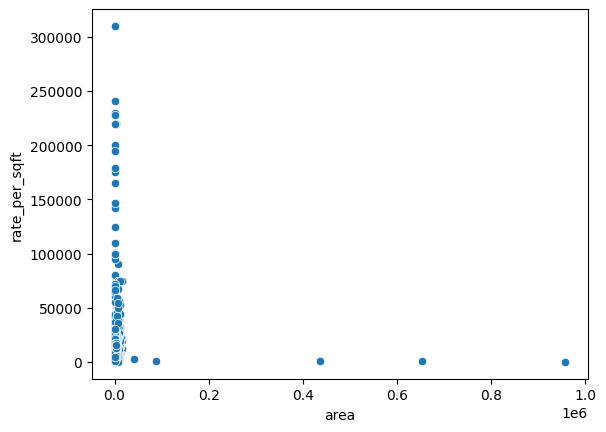

In [43]:
#? Question 10: Are larger homes always more expensive per square foot?
sns.scatterplot(x='area',y='rate_per_sqft', data=df)
plt.show()